In [1]:
from sklearn.datasets import make_regression

In [2]:
X,y=make_regression(n_samples=1000,n_features=15,n_informative=10,n_targets=1,noise=20,random_state=42)

In [6]:
X.shape

(1000, 15)

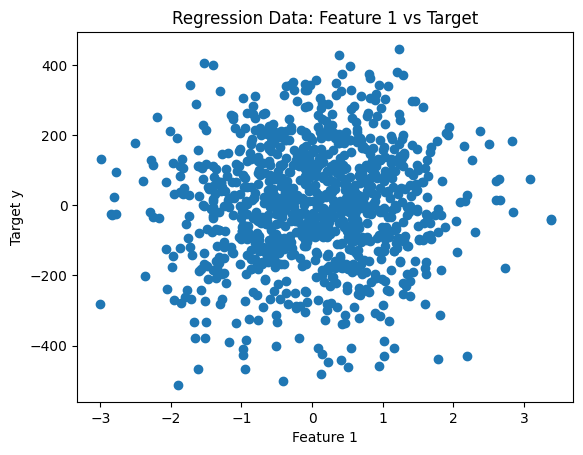

In [10]:
import matplotlib.pyplot as plt
# Plot y vs first feature
plt.figure()
plt.scatter(X[:, 0], y)
plt.xlabel("Feature 1")
plt.ylabel("Target y")
plt.title("Regression Data: Feature 1 vs Target")
plt.show()

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

In [12]:

lr = LinearRegression()
dt = DecisionTreeRegressor()
svr = SVR()

In [13]:
estimators = [('lr',lr),('dt',dt),('svr',svr)]


In [17]:
import numpy as np
for estimator in estimators:
    scores=cross_val_score(estimator[1],X,y,cv=10,scoring='r2')
    print(estimator[0],np.round(np.mean(scores),2))

lr 0.98
dt 0.51
svr 0.14


In [18]:
from sklearn.ensemble import VotingRegressor

In [22]:
vr=VotingRegressor(estimators)
scroes=cross_val_score(vr,X,y,cv=10,scoring='r2')
print("Voting Regressor",np.round(np.mean(scores),2))


Voting Regressor 0.14


In [23]:

for i in range(1,4):
  for j in range(1,4):
    for k in range(1,4):
      vr = VotingRegressor(estimators,weights=[i,j,k])
      scores = cross_val_score(vr,X,y,scoring='r2',cv=10)
      print("For i={},j={},k={}".format(i,j,k),np.round(np.mean(scores),2))

For i=1,j=1,k=1 0.78
For i=1,j=1,k=2 0.68
For i=1,j=1,k=3 0.6
For i=1,j=2,k=1 0.76
For i=1,j=2,k=2 0.7
For i=1,j=2,k=3 0.64
For i=1,j=3,k=1 0.73
For i=1,j=3,k=2 0.69
For i=1,j=3,k=3 0.66
For i=2,j=1,k=1 0.87
For i=2,j=1,k=2 0.79
For i=2,j=1,k=3 0.72
For i=2,j=2,k=1 0.84
For i=2,j=2,k=2 0.79
For i=2,j=2,k=3 0.73
For i=2,j=3,k=1 0.8
For i=2,j=3,k=2 0.77
For i=2,j=3,k=3 0.73
For i=3,j=1,k=1 0.91
For i=3,j=1,k=2 0.85
For i=3,j=1,k=3 0.79
For i=3,j=2,k=1 0.88
For i=3,j=2,k=2 0.84
For i=3,j=2,k=3 0.79
For i=3,j=3,k=1 0.85
For i=3,j=3,k=2 0.82
For i=3,j=3,k=3 0.79


In [24]:

# using the same algorithm

dt1 = DecisionTreeRegressor(max_depth=1)
dt2 = DecisionTreeRegressor(max_depth=3)
dt3 = DecisionTreeRegressor(max_depth=5)
dt4 = DecisionTreeRegressor(max_depth=7)
dt5 = DecisionTreeRegressor(max_depth=None)

In [25]:
estimators = [('dt1',dt1),('dt2',dt2),('dt3',dt3),('dt4',dt4),('dt5',dt5)]

In [26]:
for estimator in estimators:
  scores = cross_val_score(estimator[1],X,y,scoring='r2',cv=10)
  print(estimator[0],np.round(np.mean(scores),2))

dt1 0.18
dt2 0.41
dt3 0.54
dt4 0.56
dt5 0.52


In [27]:
vr = VotingRegressor(estimators)
scores = cross_val_score(vr,X,y,scoring='r2',cv=10)
print("Voting Regressor",np.round(np.mean(scores),2))

Voting Regressor 0.59
